In [8]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import func_notebook as nbk
from pathlib import Path
from scipy.signal import find_peaks
from scipy.ndimage import gaussian_filter1d
from itertools import islice
import pyarrow as py
import uproot
import awkward_pandas
import glob

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [9]:
filepath = ("/disk/gfs_atp/xlzd/alpine/run1_2/20260814T130422Z-multi-ch-100c-0-5-2-6-54v-100hz-10ns-3-3v-reuse-a7e79d09/waveforms-0000.root") 
filepath2 ="/disk/gfs_atp/xlzd/alpine/run1_2/20260814T135016Z-multi-ch-100c-0-5-2-6-58v-200hz-10ns-3-3v-d63fa17d/waveforms-0000.root"
parquet_folder = "/disk/gfs_atp/xlzd/alpine/analysis/parquets"
plot_folder = "/disk/gfs_atp/xlzd/alpine/analysis/plots"

In [10]:
data, parquet_data = nbk.analyse_root_data(filepath2,parquet_folder)

Processing ch02...
Processing ch03...
  -> Negative polarity detected on ch03. Auto-inverting.
Processing ch04...
  -> Negative polarity detected on ch04. Auto-inverting.
Processing ch05...
Processing ch06...
Processing ch14...
  -> Negative polarity detected on ch14. Auto-inverting.
Processing ch15...
Processing ch16...
  -> Negative polarity detected on ch16. Auto-inverting.
Data successfully saved  to /disk/gfs_atp/xlzd/alpine/analysis/parquets/20260814T135016Z-multi-ch-100c-0-5-2-6-58v-200hz-10ns-3-3v-d63fa17d.parquet


Sampling ch02...
Sampling ch03...
Sampling ch04...
Sampling ch05...
Sampling ch06...
Sampling ch14...
Sampling ch15...
Sampling ch16...
Combined plot saved to: /disk/gfs_atp/xlzd/alpine/analysis/plots/20260814T130422Z-multi-ch-100c-0-5-2-6-54v-100hz-10ns-3-3v-reuse-a7e79d09/combined_sample_signals.pdf


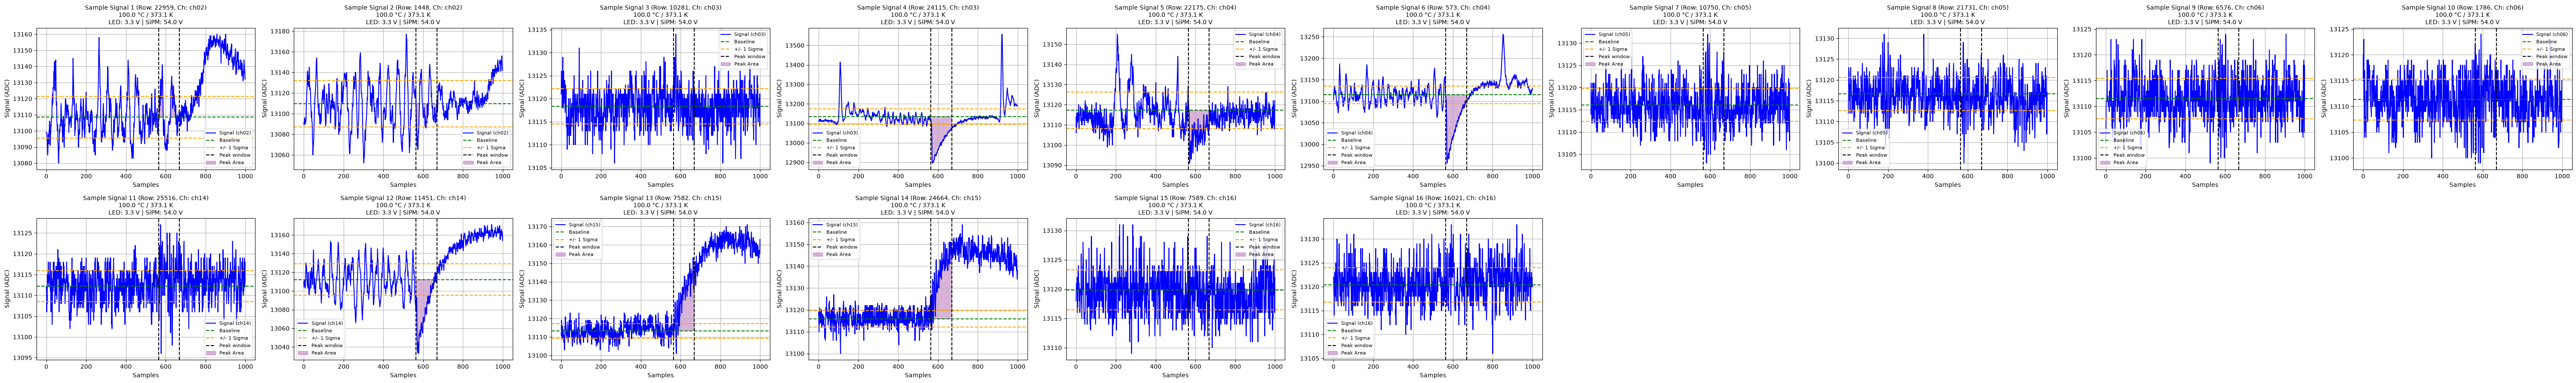

In [11]:
metadata =nbk.parse_folder_metadata(filepath)
#print(metadata)
conditions = [metadata['temp_c'], metadata['led_voltage'], metadata['bias_voltage']]
save_dir = nbk.plot_sample_signals_from_root(filepath, conditions = conditions, num_samples=2, new_path = plot_folder)

In [12]:
parquet_data  = ("/disk/gfs_atp/xlzd/alpine/analysis/parquets/20260814T130422Z-multi-ch-100c-0-5-2-6-54v-100hz-10ns-3-3v-reuse-a7e79d09.parquet")
fit_df = nbk.fit_all_channels_in_df(parquet_data ,new_path = save_dir, column_to_fit="peak_integral",max_reduced_chi2= 100)


 STARTING ANALYSIS FOR: ch02
Processing 30001 data points for ch02...
Auto-detecting peaks...
Fit rejected: Reduced χ² (637771820206009086852809697407885153861973346257403054451533207504397096958133385441449371254280289339307420002509670392431521038336.00) > threshold (100).


/home/uzh/hekinc/.venv/lib64/python3.13/site-packages/scipy/optimize/_lsq/common.py:115: RuntimeWarning: overflow encountered in power
  phi_prime = -np.sum(suf ** 2 / denom**3) / p_norm
/home/uzh/hekinc/.venv/lib64/python3.13/site-packages/scipy/optimize/_lsq/common.py:154: RuntimeWarning: divide by zero encountered in scalar divide
  ratio = phi / phi_prime
/home/uzh/hekinc/.venv/lib64/python3.13/site-packages/scipy/optimize/_lsq/common.py:166: RuntimeWarning: divide by zero encountered in scalar divide
  p *= Delta / norm(p)
/home/uzh/hekinc/.venv/lib64/python3.13/site-packages/scipy/optimize/_lsq/common.py:166: RuntimeWarning: invalid value encountered in multiply
  p *= Delta / norm(p)
/home/uzh/hekinc/.venv/lib64/python3.13/site-packages/scipy/optimize/_lsq/common.py:398: RuntimeWarning: invalid value encountered in cast
  return min_step, np.equal(steps, min_step) * np.sign(s).astype(int)
/home/uzh/hekinc/.venv/lib64/python3.13/site-packages/scipy/optimize/_lsq/common.py:283: Ru


 STARTING ANALYSIS FOR: ch03
Processing 30001 data points for ch03...
Auto-detecting peaks...
Physics Curve fitting converged successfully!

--- Physical Fit Results for ch03 ---
  0-Photon Peak: μ = 1.787949e+00, σ = 1.731472e+02
  1-Photon Peak: μ = 7.723979e+02, σ = 2.572526e+02
  2-Photon Peak: μ = 1.543008e+03, σ = 3.199654e+02
  3-Photon Peak: μ = 2.313618e+03, σ = 3.722590e+02
--------------------------------------------------
χ² / NDF:           3130.48 / 476 = 6.577
----------------------------

 STARTING ANALYSIS FOR: ch04
Processing 30001 data points for ch04...
Auto-detecting peaks...
Physics Curve fitting converged successfully!

--- Physical Fit Results for ch04 ---
  0-Photon Peak: μ = 2.996810e-01, σ = 1.124339e+02
  1-Photon Peak: μ = 1.769449e+03, σ = 7.029203e+02
  2-Photon Peak: μ = 3.538598e+03, σ = 9.877006e+02
  3-Photon Peak: μ = 5.307747e+03, σ = 1.207066e+03
--------------------------------------------------
χ² / NDF:           1240.86 / 476 = 2.607
---------

/home/uzh/hekinc/Master/Python/func_notebook.py:122: RuntimeWarning: overflow encountered in exp
  y = A_bg * np.exp(-lambda_bg * x)
/home/uzh/hekinc/Master/Python/func_notebook.py:122: RuntimeWarning: overflow encountered in multiply
  y = A_bg * np.exp(-lambda_bg * x)
/home/uzh/hekinc/.venv/lib64/python3.13/site-packages/scipy/optimize/_lsq/trf.py:353: RuntimeWarning: overflow encountered in dot
  cost_new = 0.5 * np.dot(f_new, f_new)
/home/uzh/hekinc/.venv/lib64/python3.13/site-packages/scipy/optimize/_lsq/common.py:115: RuntimeWarning: invalid value encountered in scalar divide
  phi_prime = -np.sum(suf ** 2 / denom**3) / p_norm



 STARTING ANALYSIS FOR: ch14
Processing 30001 data points for ch14...
Auto-detecting peaks...
Physics Curve fitting converged successfully!

--- Physical Fit Results for ch14 ---
  0-Photon Peak: μ = 6.133806e+00, σ = 1.277061e+02
  1-Photon Peak: μ = 1.370096e+03, σ = 8.197646e+02
  2-Photon Peak: μ = 2.734058e+03, σ = 1.152267e+03
  3-Photon Peak: μ = 4.098019e+03, σ = 1.408341e+03
--------------------------------------------------
χ² / NDF:           1270.86 / 476 = 2.670
----------------------------

 STARTING ANALYSIS FOR: ch15
Processing 30001 data points for ch15...
Auto-detecting peaks...
Physics Curve fitting converged successfully!

--- Physical Fit Results for ch15 ---
  0-Photon Peak: μ = -3.466484e+01, σ = 8.571714e+01
  1-Photon Peak: μ = 9.910936e+02, σ = 1.061776e+02
  2-Photon Peak: μ = 2.016852e+03, σ = 1.232880e+02
  3-Photon Peak: μ = 3.042611e+03, σ = 1.382974e+02
--------------------------------------------------
χ² / NDF:           2457.94 / 476 = 5.164
--------

/home/uzh/hekinc/.venv/lib64/python3.13/site-packages/numpy/linalg/_linalg.py:2767: RuntimeWarning: overflow encountered in dot
  sqnorm = x.dot(x)
/home/uzh/hekinc/.venv/lib64/python3.13/site-packages/scipy/optimize/_lsq/common.py:141: RuntimeWarning: invalid value encountered in scalar multiply
  alpha = max(0.001 * alpha_upper, (alpha_lower * alpha_upper)**0.5)
/home/uzh/hekinc/.venv/lib64/python3.13/site-packages/scipy/optimize/_lsq/common.py:115: RuntimeWarning: overflow encountered in square
  phi_prime = -np.sum(suf ** 2 / denom**3) / p_norm
/home/uzh/hekinc/.venv/lib64/python3.13/site-packages/scipy/optimize/_lsq/common.py:115: RuntimeWarning: invalid value encountered in divide
  phi_prime = -np.sum(suf ** 2 / denom**3) / p_norm
/home/uzh/hekinc/.venv/lib64/python3.13/site-packages/scipy/optimize/_lsq/common.py:282: RuntimeWarning: overflow encountered in dot
  v = J.dot(s)
/home/uzh/hekinc/.venv/lib64/python3.13/site-packages/scipy/optimize/_lsq/common.py:285: RuntimeWarning:


All plots successfully saved to /disk/gfs_atp/xlzd/alpine/analysis/plots/20260814T130422Z-multi-ch-100c-0-5-2-6-54v-100hz-10ns-3-3v-reuse-a7e79d09/all_channels_canvas.pdf


Heatmaps saved to: /disk/gfs_atp/xlzd/alpine/analysis/plots/20260814T130422Z-multi-ch-100c-0-5-2-6-54v-100hz-10ns-3-3v-reuse-a7e79d09/heatmaps_all_channels.pdf


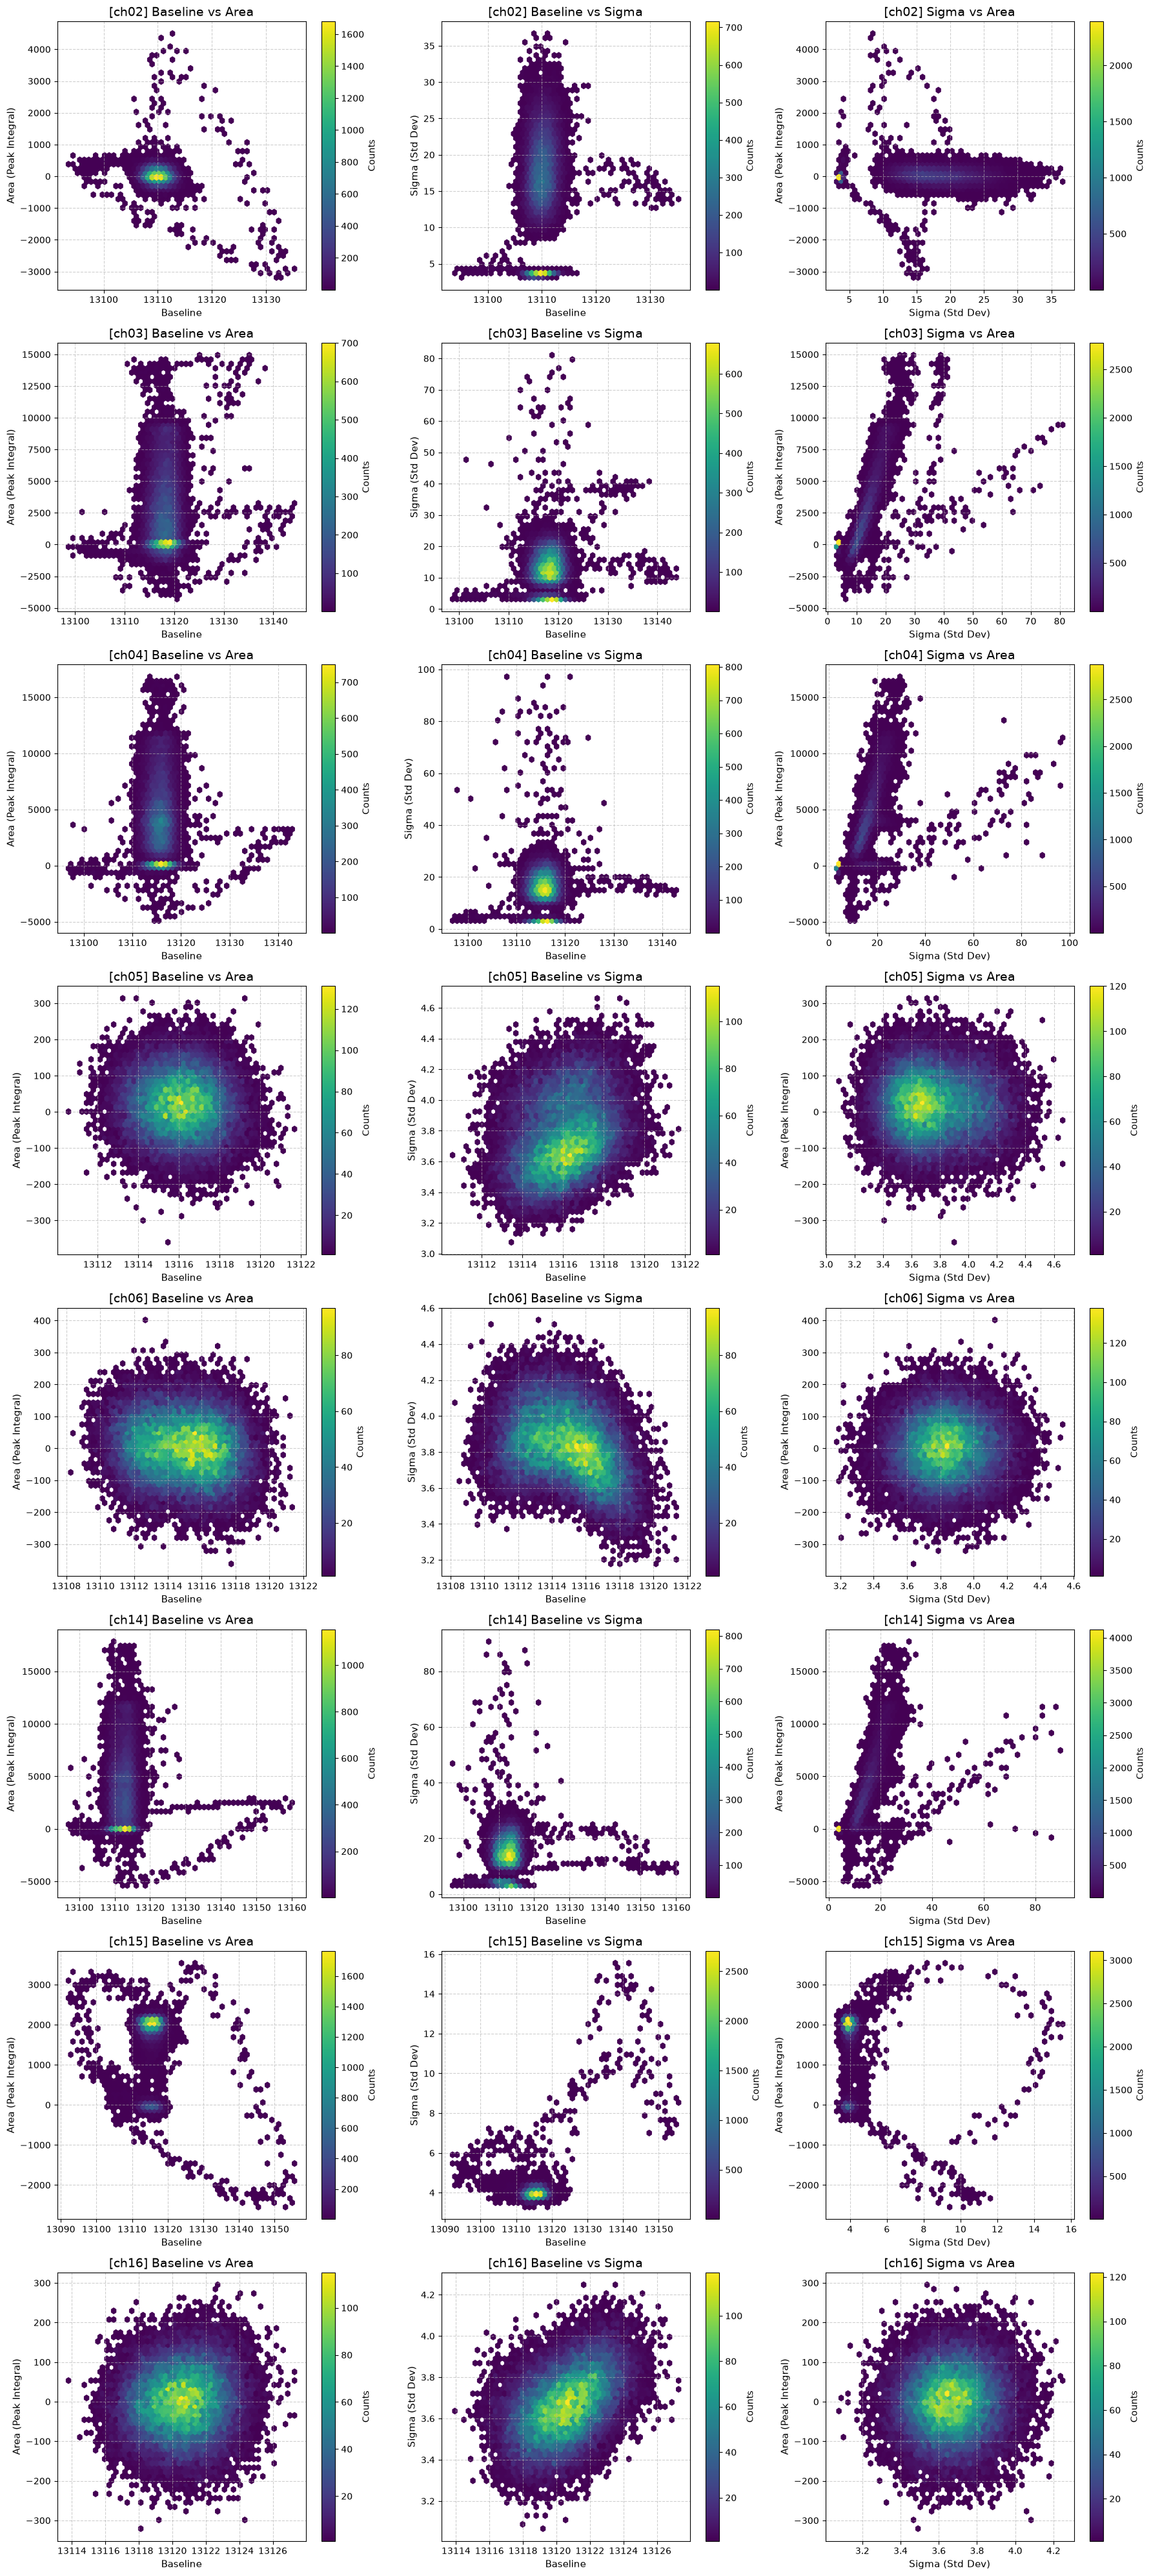

In [13]:
nbk.plot_waveform_correlations(parquet_data,new_path = save_dir, channel=None, plot_type='hexbin')

Processing ch02...
Processing ch03...
  -> Negative polarity detected on ch03. Auto-inverting.
Processing ch04...
  -> Negative polarity detected on ch04. Auto-inverting.
Processing ch05...
Processing ch06...
Processing ch14...
  -> Negative polarity detected on ch14. Auto-inverting.
Processing ch15...
Processing ch16...
  -> Negative polarity detected on ch16. Auto-inverting.
Data successfully saved  to /disk/gfs_atp/xlzd/alpine/analysis/parquets/20260814T135016Z-multi-ch-100c-0-5-2-6-58v-200hz-10ns-3-3v-d63fa17d.parquet
Sampling ch02...
Sampling ch03...
Sampling ch04...
Sampling ch05...
Sampling ch06...
Sampling ch14...
Sampling ch15...
Sampling ch16...
Combined plot saved to: /disk/gfs_atp/xlzd/alpine/analysis/plots/20260814T135016Z-multi-ch-100c-0-5-2-6-58v-200hz-10ns-3-3v-d63fa17d/combined_sample_signals.pdf


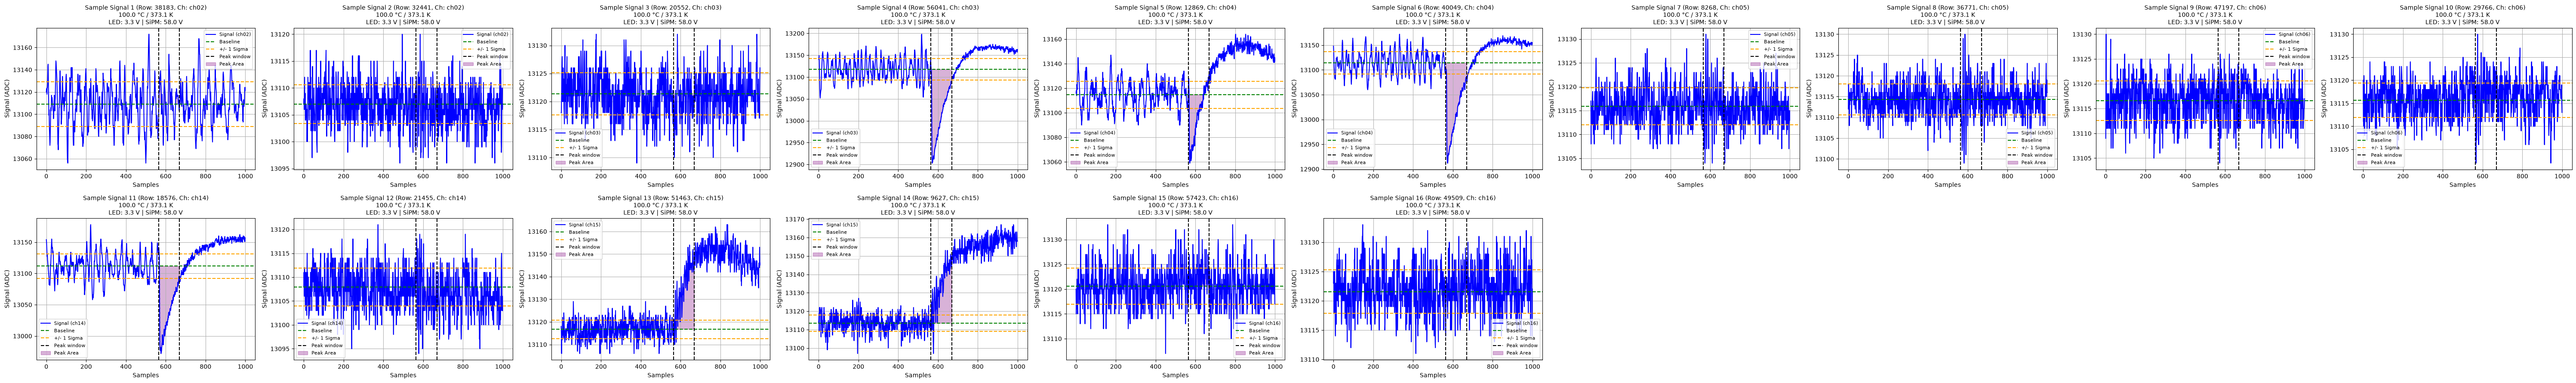


 STARTING ANALYSIS FOR: ch02
Processing 60001 data points for ch02...
Auto-detecting peaks...


/home/uzh/hekinc/Master/Python/func_notebook.py:19: RuntimeWarning: overflow encountered in exp
  baseline_end_64 = 530
/home/uzh/hekinc/Master/Python/func_notebook.py:19: RuntimeWarning: overflow encountered in multiply
  baseline_end_64 = 530


Physics Curve fitting converged successfully!

--- Physical Fit Results for ch02 ---
  0-Photon Peak: μ = -3.452868e+01, σ = 1.506242e+02
  1-Photon Peak: μ = 2.754270e+02, σ = 1.506246e+02
  2-Photon Peak: μ = 5.853827e+02, σ = 1.506251e+02
  3-Photon Peak: μ = 8.953383e+02, σ = 1.506255e+02
--------------------------------------------------
χ² / NDF:           1798.93 / 476 = 3.779
----------------------------

 STARTING ANALYSIS FOR: ch03
Processing 60001 data points for ch03...
Auto-detecting peaks...
Physics Curve fitting converged successfully!

--- Physical Fit Results for ch03 ---
  0-Photon Peak: μ = -2.385813e+02, σ = 6.016942e+02
  1-Photon Peak: μ = 7.208638e+03, σ = 1.697810e+03
  2-Photon Peak: μ = 1.465586e+04, σ = 2.324452e+03
  3-Photon Peak: μ = 2.210308e+04, σ = 2.814889e+03
--------------------------------------------------
χ² / NDF:           19110.40 / 476 = 40.148
----------------------------

 STARTING ANALYSIS FOR: ch04
Processing 60001 data points for ch04...


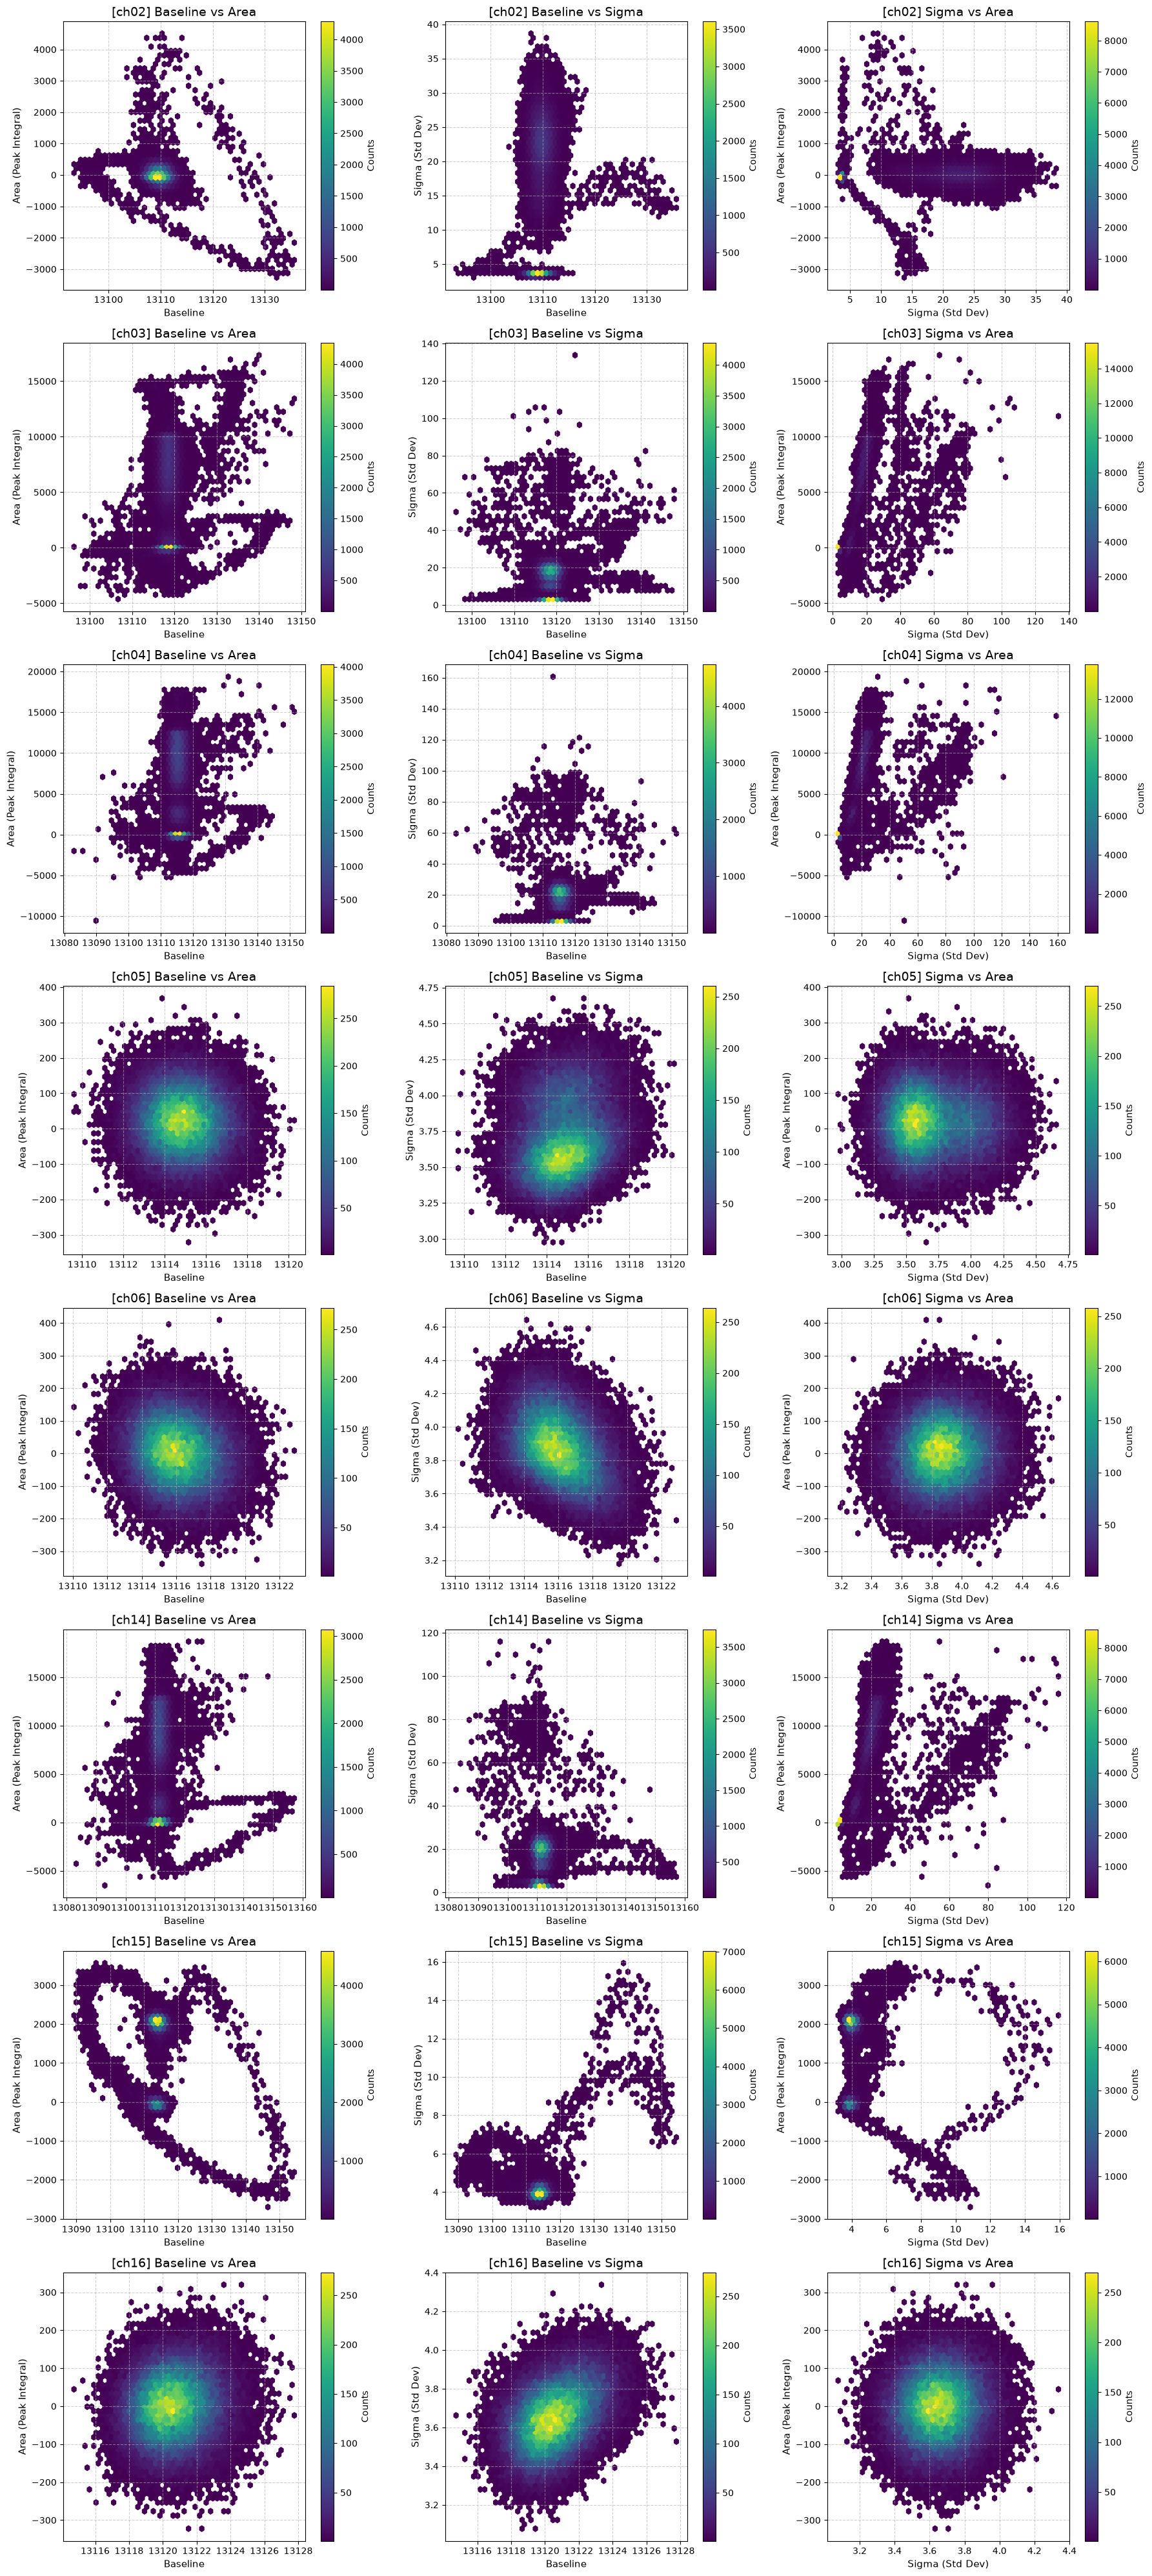

In [18]:
nbk.master_function_root(filepath2)